# 05 — Hit Calling

Identifies active compounds from normalized single-point screening data.

**Requires:** `data/processed/all_plates_normalized.csv`

In [1]:
%matplotlib inline
import pandas as pd
import matplotlib.pyplot as plt

norm_df = pd.read_csv('data/processed/all_plates_normalized.csv')
exp_df  = norm_df[norm_df['WellType'] == 'Experimental'].copy()
print(f'Total experimental wells: {len(exp_df)}')

Total experimental wells: 1600


## Hit threshold: > 50% activity

In [2]:
hits_50 = exp_df[exp_df['Pct_Activity'] > 50].sort_values(
    ['Plate', 'Pct_Activity'], ascending=[True, False])

print(f'Hits > 50%: {len(hits_50)}')
print(hits_50.groupby('Plate')['Well'].count().rename('Hits >50%').to_string())

Hits > 50%: 1109
Plate
Plate 1    221
Plate 2    226
Plate 3    215
Plate 4    228
Plate 5    219


## Hit refinement: > 75% activity

In [3]:
hits_75 = exp_df[exp_df['Pct_Activity'] > 75].sort_values(
    ['Plate', 'Pct_Activity'], ascending=[True, False])

print(f'Hits > 75%: {len(hits_75)}')
print(hits_75.groupby('Plate')['Well'].count().rename('Hits >75%').to_string())
print('\nTop 10 hits:')
print(hits_75.nlargest(10, 'Pct_Activity')[['Plate','Well','Pct_Activity']].to_string(index=False))

Hits > 75%: 694
Plate
Plate 1    141
Plate 2    132
Plate 3    136
Plate 4    147
Plate 5    138

Top 10 hits:
  Plate Well  Pct_Activity
Plate 5  D14        177.43
Plate 5  F03        177.43
Plate 5  K19        177.43
Plate 2  N05        176.23
Plate 1  I18        175.06
Plate 3  I14        173.61
Plate 4  C10        173.24
Plate 1  H12        169.31
Plate 2  O15        167.89
Plate 4  L13        164.35


## Activity distribution plot

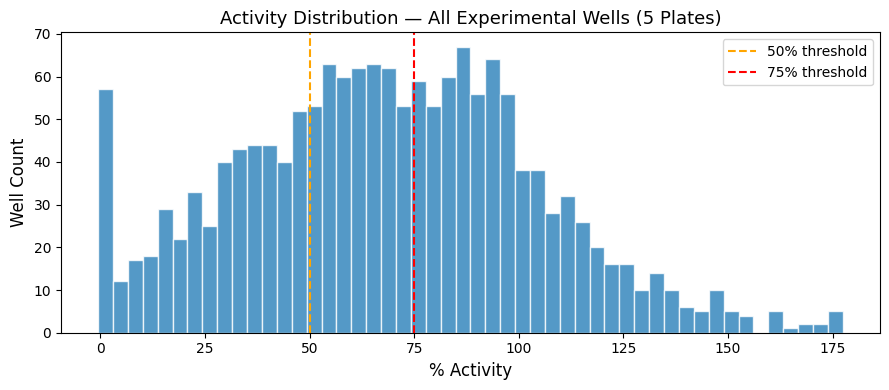

In [4]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(exp_df['Pct_Activity'], bins=50, color='#2980b9', edgecolor='white', alpha=0.8)
ax.axvline(50, color='orange', linestyle='--', linewidth=1.5, label='50% threshold')
ax.axvline(75, color='red',    linestyle='--', linewidth=1.5, label='75% threshold')
ax.set_xlabel('% Activity', fontsize=12)
ax.set_ylabel('Well Count', fontsize=12)
ax.set_title('Activity Distribution — All Experimental Wells (5 Plates)', fontsize=13)
ax.legend()
plt.tight_layout()
plt.savefig('data/results/activity_distribution.png', dpi=150)
plt.show()

## Save hit lists

In [5]:
hits_50.to_csv('data/results/hits_50pct.csv', index=False)
hits_75.to_csv('data/results/hits_75pct.csv', index=False)
print(f'Saved: data/results/hits_50pct.csv ({len(hits_50)} hits)')
print(f'Saved: data/results/hits_75pct.csv ({len(hits_75)} hits)')

Saved: data/results/hits_50pct.csv (1109 hits)
Saved: data/results/hits_75pct.csv (694 hits)
